#                                   Heart Disease Risk Prediction
### Research Questions
**RQ1.** Logistic Regression và SVC khác nhau như thế nào về ROC-AUC, PR-AUC, và F1-score?

**RQ2.** Khi thay đổi decision threshold, trade-off giữa precision, recall, và F1 thay đổi ra sao?

**RQ3.** Xác suất đầu ra của Logistic Regression và SVC có đủ tốt để dùng như một risk score không? (Calibration analysis)

# I. Import Libraries

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_validate
from sklearn import set_config
set_config(display='text')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, average_precision_score, f1_score,
    precision_recall_curve, roc_curve, auc , precision_score, recall_score
)

import warnings
warnings.filterwarnings('ignore')

## Seed tái lập kết quả  

In [46]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# II. Load Data



In [47]:

DATA_PATH = r"D:\\ki_4\DAP303m\\heart disease\data.csv"

# if not os.path.exists(DATA_PATH):
#     print("Không tìm thấy:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
df.head(5)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2.1 Problem Formulation and Target Transformation

Trong nghiên cứu này, nhãn gốc được chuyển thành nhị phân:

\[
y =
\begin{cases}
0, & \text{if } num = 0 \\
1, & \text{if } num > 0
\end{cases}
\]

### Ý nghĩa
- đơn giản hóa bài toán thành binary classification
- phù hợp với mục tiêu phát hiện bệnh nhân có nguy cơ
- dễ áp dụng ROC-AUC, PR-AUC, F1


### 2.2 Feature Description

| Feature | Type | Description |
|--------|------|-------------|
| age | Numerical | Age of the patient in years. |
| sex | Categorical | Gender of the patient (1 = male, 0 = female). |
| cp | Categorical | Chest pain type: 1 = Typical angina, 2 = Atypical angina, 3 = Non-anginal pain, 4 = Asymptomatic. |
| trestbps | Numerical | Resting systolic blood pressure measured at hospital admission (mm Hg). |
| chol | Numerical | Serum cholesterol level measured in mg/dl. |
| fbs | Binary | Indicates whether fasting blood sugar > 120 mg/dl (1 = True, 0 = False). |
| restecg | Categorical | Resting electrocardiographic results: 0 = Normal, 1 = ST-T wave abnormality, 2 = There are signs of left ventricular hypertrophy. |
| thalach | Numerical | Maximum heart rate achieved during the exercise test. |
| exang | Binary | Exercise-induced angina (1 = Yes, 0 = No). |
| oldpeak | Numerical | ST depression induced by exercise relative to rest. |
| slope | Categorical | Slope of the peak exercise ST segment: 1 = Upsloping, 2 = Flat, 3 = Downsloping. |
| ca | Numerical | Number of major coronary vessels (0–3) observed via fluoroscopy. |
| thal | Categorical | Thalassemia test result: 3 = Normal, 6 = Fixed defect, 7 = Reversible defect. |
| num | Target | Diagnosis of heart disease: 0 = No heart disease (<50% diameter narrowing), 1–4 = Presence of heart disease (>50% diameter narrowing).

In [48]:
df = df.replace('?', np.nan).copy()
target_col = None
for c in ["num", "target"]:
    if c in df.columns:
        target_col = c
        break
if target_col is None:
    raise ValueError("Không tìm thấy cột 'num' hoặc 'target'.")

# target binary
df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df["y"] = (df[target_col] > 0).astype(int)

print("Target column:", target_col)
print("Binary class distribution:")
print(df["y"].value_counts())
print("Binary class ratio:")
print(df["y"].value_counts(normalize=True).round(4))


Target column: target
Binary class distribution:
y
0    164
1    139
Name: count, dtype: int64
Binary class ratio:
y
0    0.5413
1    0.4587
Name: proportion, dtype: float64


===== MISSING VALUES (BEFORE FIX) =====
ca      4
thal    2


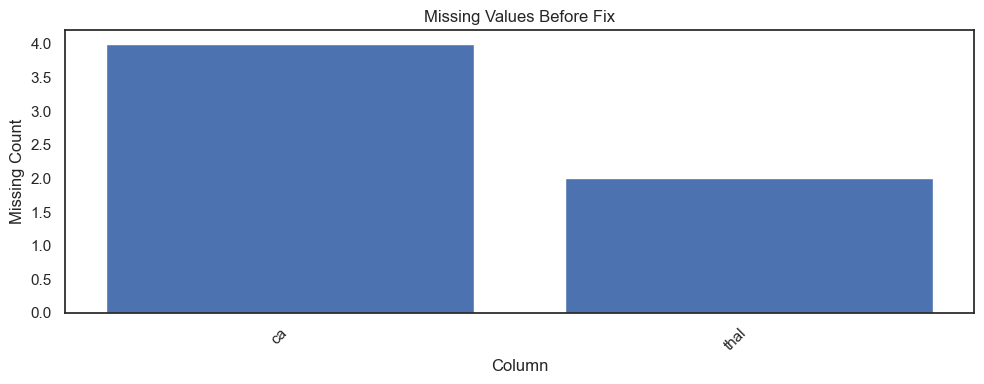

In [49]:
missing_before = df.isna().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

print("===== MISSING VALUES (BEFORE FIX) =====")
if len(missing_before) == 0:
    print("No missing values.")
else:
    print(missing_before.to_string())
    plt.figure(figsize=(10,4))
    plt.bar(missing_before.index.astype(str), missing_before.values)
    plt.title("Missing Values Before Fix")
    plt.xlabel("Column")
    plt.ylabel("Missing Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


===== MISSING (AFTER FIX) =====
No missing values AFTER fix.


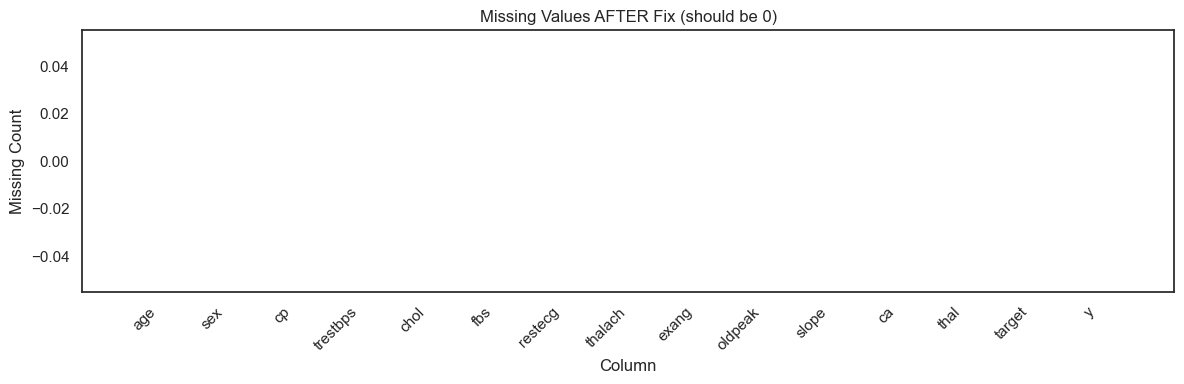

In [50]:
df_fix = df.copy()

# numeric -> median
for c in numeric_features:
    df_fix[c] = pd.to_numeric(df_fix[c], errors="coerce")
    df_fix[c] = df_fix[c].fillna(df_fix[c].median())

# categorical -> most_frequent
for c in categorical_features:
    if df_fix[c].isna().any():
        mode_val = df_fix[c].mode(dropna=True)
        df_fix[c] = df_fix[c].fillna(mode_val.iloc[0] if len(mode_val) else "Unknown")

missing_after = df_fix.isna().sum()
missing_after = missing_after[missing_after > 0]

print("===== MISSING (AFTER FIX) =====")
if len(missing_after) == 0:
    print("No missing values AFTER fix.")
else:
    print("Still missing:")
    print(missing_after.to_string())

plt.figure(figsize=(12,4))
plt.bar(df_fix.columns.astype(str), df_fix.isna().sum().values)
plt.title("Missing Values AFTER Fix (should be 0)")
plt.xlabel("Column")
plt.ylabel("Missing Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# III. EDA

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    object 
 12  thal      301 non-null    object 
 13  target    303 non-null    int64  
 14  y         303 non-null    int64  
dtypes: float64(11), int64(2), object(2)
memory usage: 35.6+ KB


## 3.1 Load Dataset and Process Columns
Define and process categorical and numerical columns by converting them to appropriate data types

### Numeric features
- age
- trestbps
- chol
- thalach
- oldpeak

### Categorical features
- sex
- cp
- fbs
- restecg
- exang
- slope
- ca
- thal


In [52]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# type vale
for col in categorical_cols:
  if col in df.columns:
    df[col] = df[col].astype('category')

for col in numerical_cols:
  if col in df.columns:
    df[col] = pd.to_numeric(df[col], errors = 'coerce')

categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']

print()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       303 non-null    float64 
 1   sex       303 non-null    category
 2   cp        303 non-null    category
 3   trestbps  303 non-null    float64 
 4   chol      303 non-null    float64 
 5   fbs       303 non-null    category
 6   restecg   303 non-null    category
 7   thalach   303 non-null    float64 
 8   exang     303 non-null    category
 9   oldpeak   303 non-null    float64 
 10  slope     303 non-null    category
 11  ca        299 non-null    category
 12  thal      301 non-null    category
 13  target    303 non-null    category
 14  y         303 non-null    int64   
dtypes: category(9), float64(5), int64(1)
memory usage: 18.4 KB


In [53]:
print('Null values:')
print(df.isnull().sum())
print("\nDuplicate Rows Count:", df.duplicated().sum())

Null values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
y           0
dtype: int64

Duplicate Rows Count: 0


In [54]:
df.describe()

,age,trestbps,chol,thalach,oldpeak,y
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,131.689769,246.693069,149.607261,1.039604,0.458746
std,9.038662,17.599748,51.776918,22.875003,1.161075,0.499120
min,29.000000,94.000000,126.000000,71.000000,0.000000,0.000000
25%,48.000000,120.000000,211.000000,133.500000,0.000000,0.000000
50%,56.000000,130.000000,241.000000,153.000000,0.800000,0.000000
75%,61.000000,140.000000,275.000000,166.000000,1.600000,1.000000
max,77.000000,200.000000,564.000000,202.000000,6.200000,1.000000


## Summary:

*   The dataset 303 rows and 14 columns.

**Column data types were processed:**
 - 9 columns (`sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal`, `target`) were converted to `category` type, and
 - 5 columns (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`) were converted to `float64` (numeric) type.

* No duplicated values
- Missing values in the **ca (4)** and **thal (2)** features.

## 3.2 Visualization

### Oulier

Boxplot for Numerical Columns


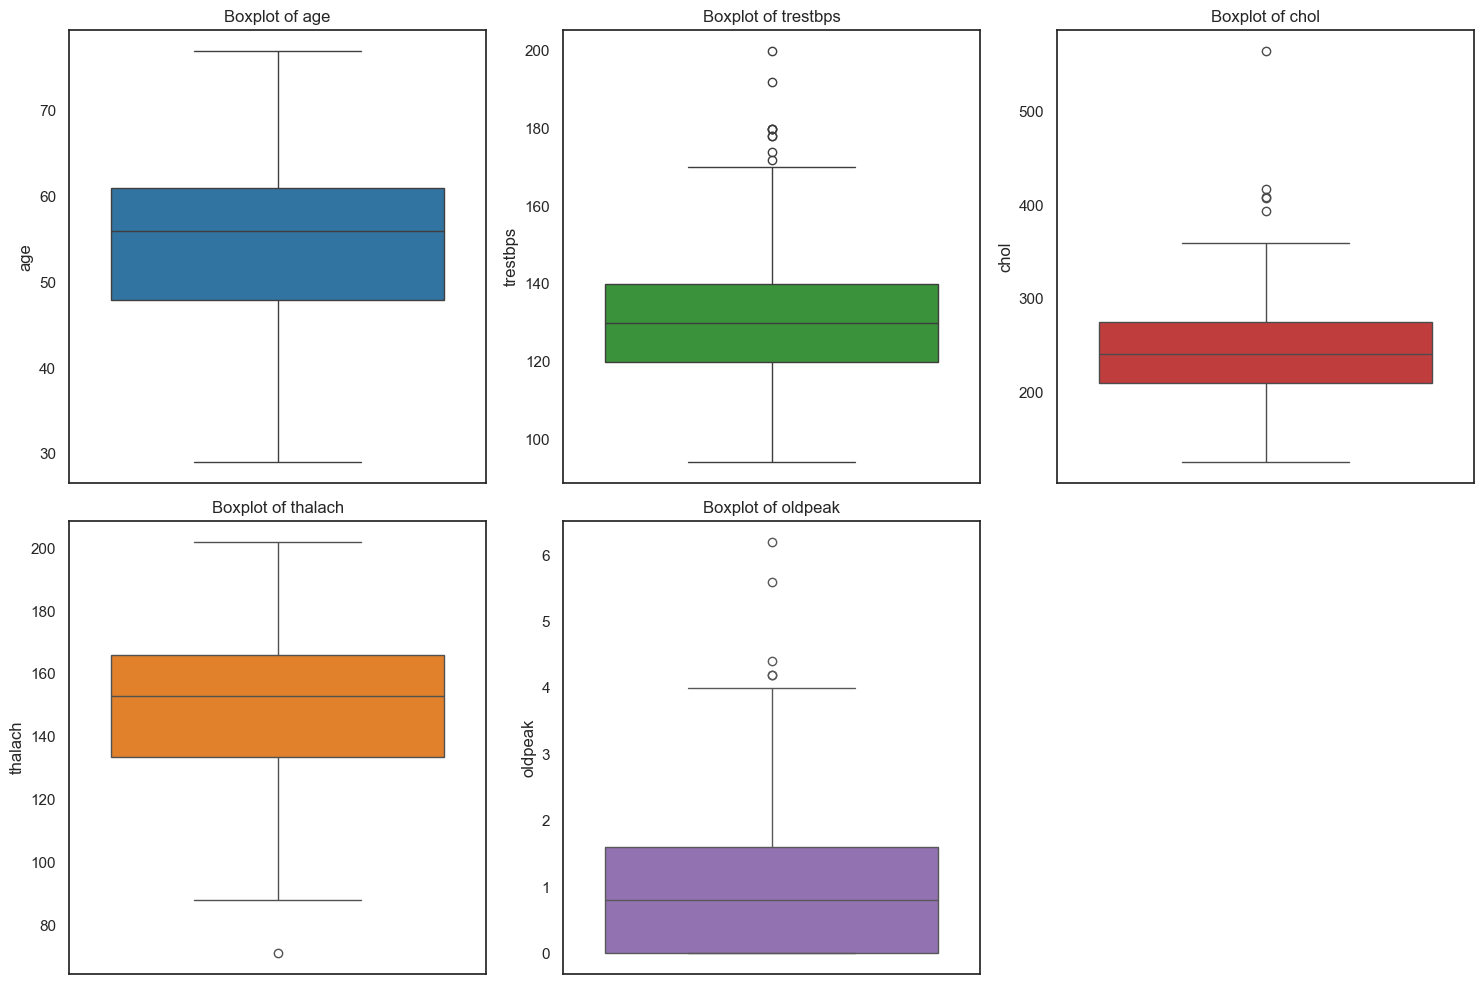

In [55]:
colors = ["#1f77b4", "#2ca02c", "#d62728", "#ff7f0e", "#9467bd"]

print('Boxplot for Numerical Columns')
plt.figure(figsize = (15,10))
for i, col in enumerate(numerical_cols,1):
  plt.subplot(2,3,i)
  sns.boxplot(y = df[col], color = colors[i-1] )
  plt.title(f'Boxplot of {col}')
  plt.ylabel(col)

plt.tight_layout()
plt.show()

### Boxplot Analysis
- **age** shows a relatively symmetric distribution with no significant outliers.
- **trestbps** (resting blood pressure) contains several upper outliers, indicating some individuals have unusually high blood pressure values.
- **chol** (serum cholesterol) also presents multiple high-value outliers, suggesting possible extreme cholesterol levels in a few patients.
- **thalach** (maximum heart rate achieved) appears fairly normally distributed with only a few low-value outliers.
- **oldpeak** exhibits noticeable outliers and a right-skewed distribution, meaning some patients experience significantly higher ST depression values.

--> These outliers may represent real medical conditions rather than data errors.

chol: 5 outliers
trestbps: 9 outliers
oldpeak: 5 outliers


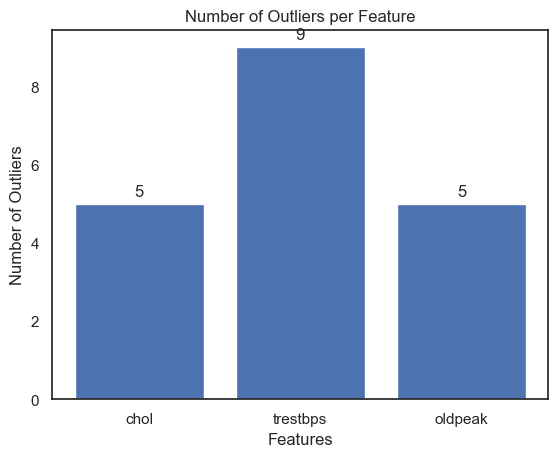

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

cols = ['chol', 'trestbps', 'oldpeak']

outlier_counts = {}

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

# In ra kết quả
for col, count in outlier_counts.items():
    print(f"{col}: {count} outliers")

# ===== VẼ BIỂU ĐỒ =====
features = list(outlier_counts.keys())
counts = list(outlier_counts.values())

plt.figure()
plt.bar(features, counts)

plt.title('Number of Outliers per Feature')
plt.xlabel('Features')
plt.ylabel('Number of Outliers')

# Hiển thị số trên cột
for i, v in enumerate(counts):
    plt.text(i, v + 0.2, str(v), ha='center')

plt.show()

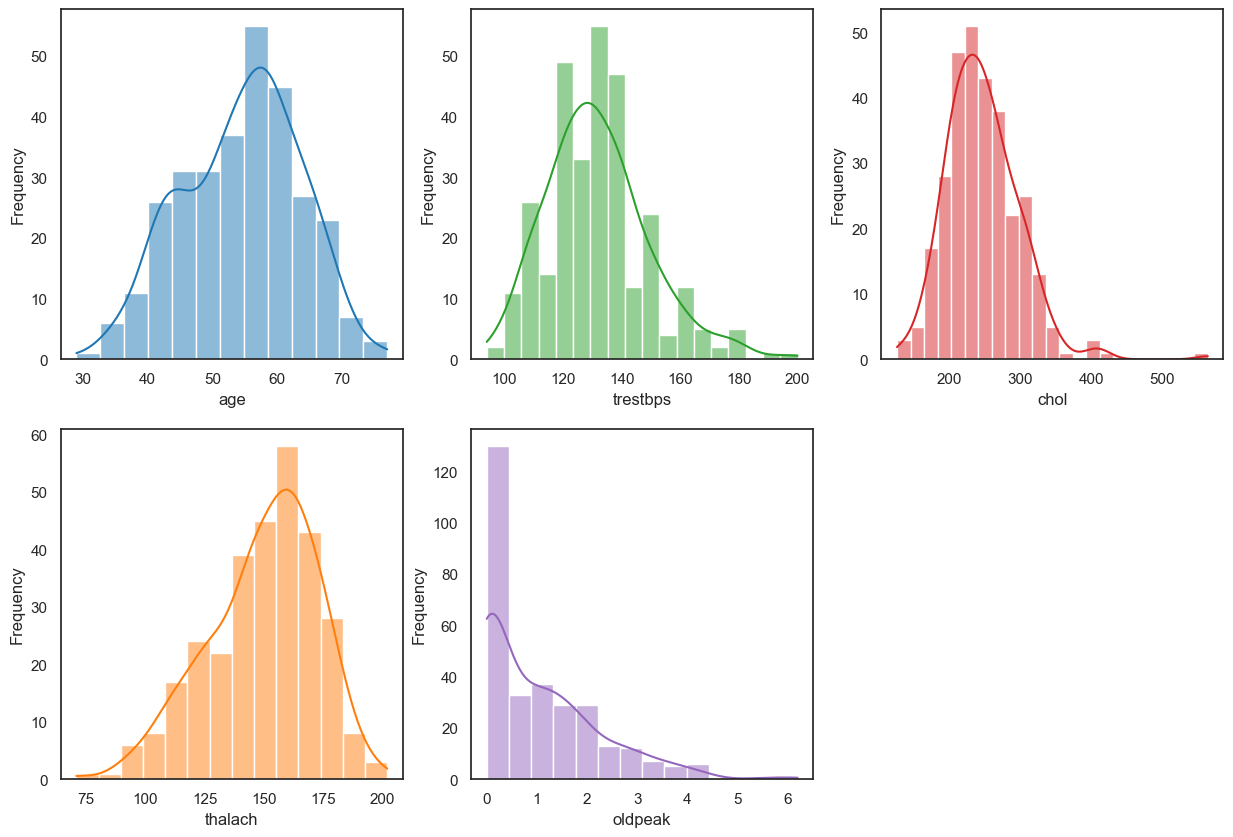

In [57]:
# Histogram
plt.figure(figsize = (15,10))
for i, col in enumerate(numerical_cols, 1):
  plt.subplot(2,3,i)
  sns.histplot(df[col] , kde = True, color = colors[i-1])
  plt.ylabel('Frequency')
  plt.xlabel(col)

plt.show()

### Distribution of Numerical Features

- **Age**: The age of patients is mostly concentrated between **45 and 65 years**, with a roughly normal distribution centered around the mid-50s.

- **Resting Blood Pressure (trestbps)**: Most values fall in the range of **110–150 mmHg**, indicating typical resting blood pressure levels for the majority of patients.

- **Cholesterol (chol)**: Cholesterol levels are mainly distributed between **200 and 300 mg/dl**, though a few higher values appear as potential outliers.

- **Maximum Heart Rate Achieved (thalach)**: The distribution peaks around **140–170 bpm**, showing that most patients reached relatively high heart rates during exercise tests.

- **ST Depression (oldpeak)**: This variable is **right-skewed**, with many observations close to **0**, meaning most patients show little ST depression during exercise.

**Overall observation:**  
Most numerical features show reasonable distributions with some skewness in `chol` and `oldpeak`. These variables may contain outliers or non-normal distributions

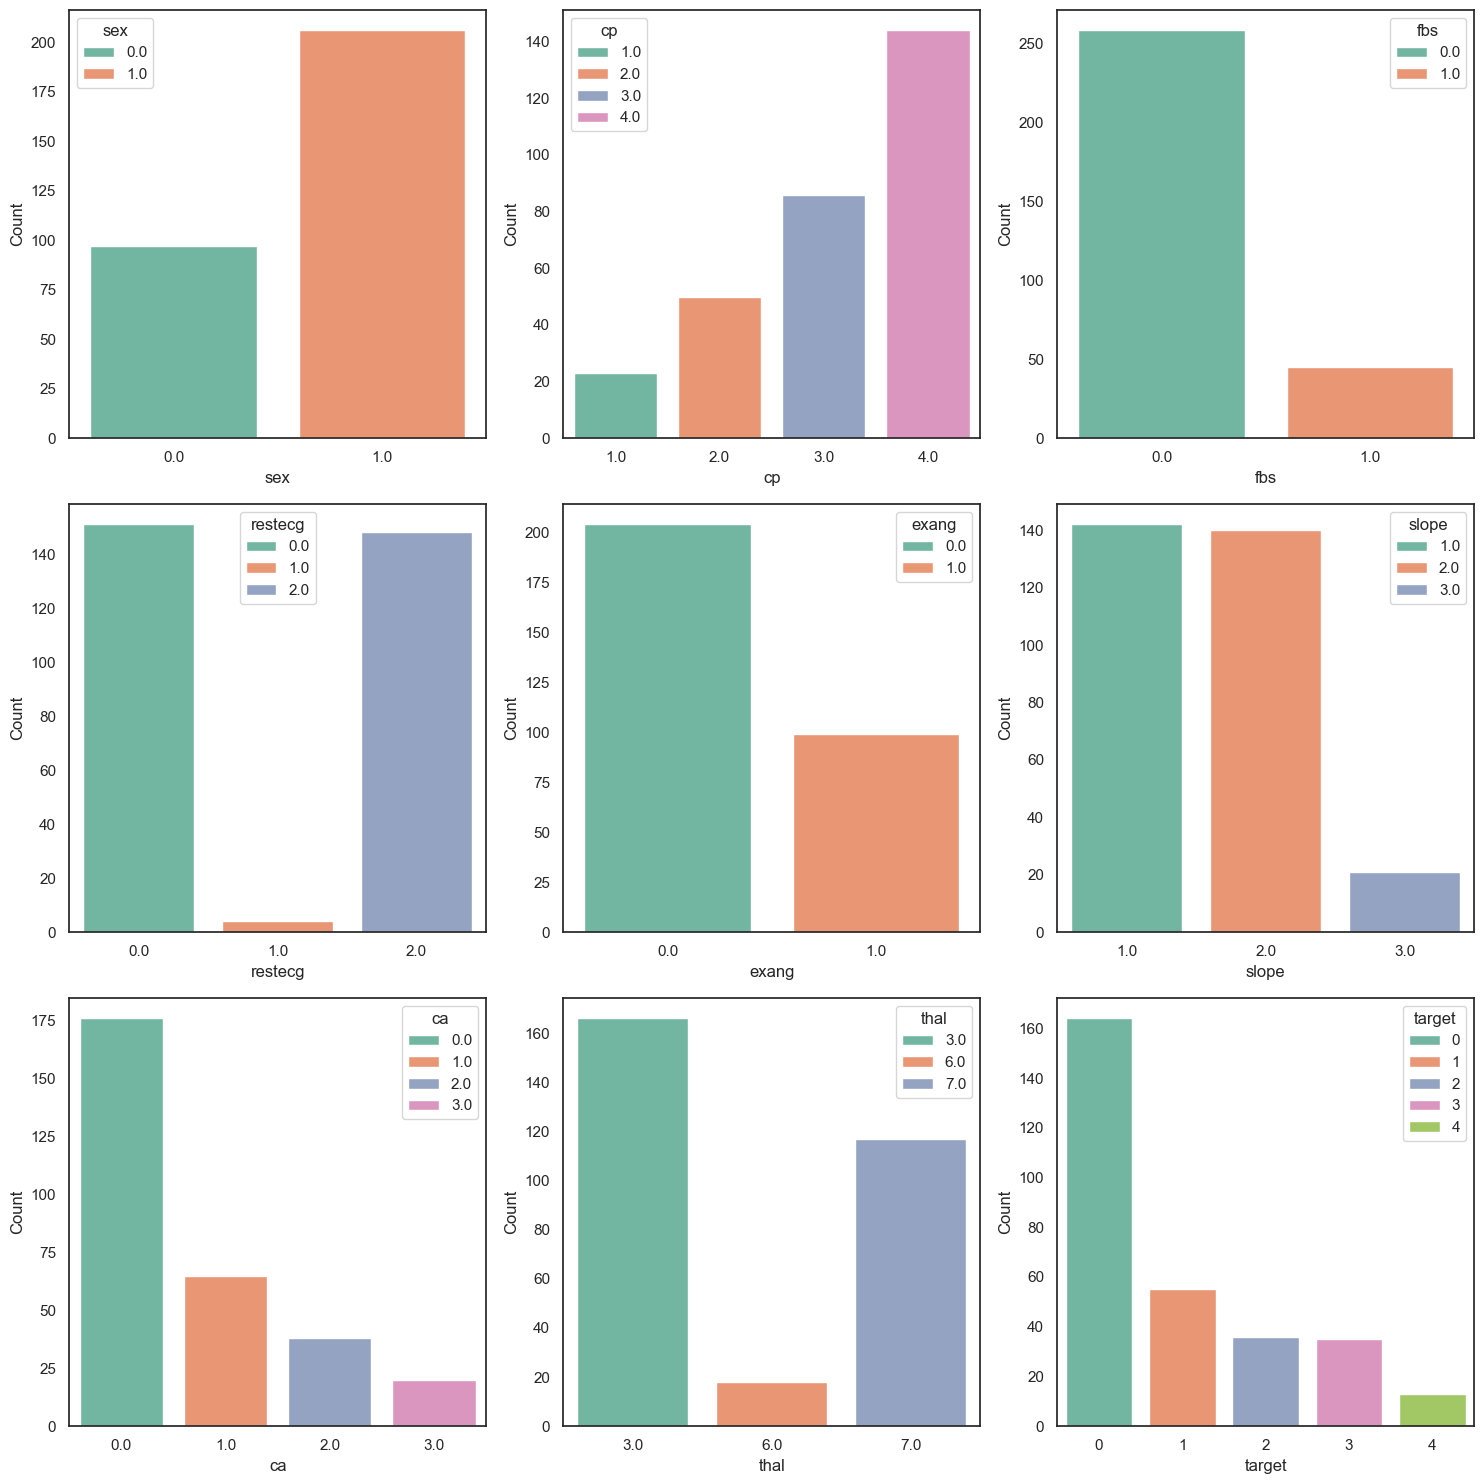

In [58]:
# 3. Bar plots for categorical variables
plt.figure(figsize=(15, 15))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(
        x=col,
        hue=col,
        data=df,
        palette='Set2',
        legend=True
    )
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Distribution of Categorical Features

The bar charts show the distribution of categorical variables in the dataset.

- **Sex:** Male patients are more common than female patients.
- **Chest Pain (cp):** Type 4 (asymptomatic) appears most frequently.
- **Fasting Blood Sugar (fbs):** Most patients have normal fasting blood sugar (≤120 mg/dl).
- **Resting ECG (restecg):** Categories 0 and 2 are common, while category 1 is rare.
- **Exercise-Induced Angina (exang):** Most patients do not experience exercise-induced angina.
- **Slope:** Categories 1 and 2 are dominant, while category 3 is less frequent.
- **Number of Vessels (ca):** Most patients have 0 major vessels detected.
- **Thalassemia (thal):** Categories 3 and 7 appear more often than category 6.
- **Target:** Class 0 (no heart disease) appears slightly more often than other classes.

**Overall:**  
Most categorical variables show uneven distributions, which may provide useful information for classification models.

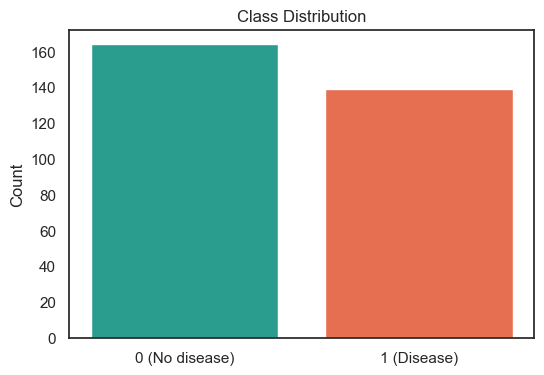

In [59]:
class_count = df['y'].value_counts()

plt.figure(figsize = (6,4))
plt.title('Class Distribution')
plt.bar(["0 (No disease)", "1 (Disease)"], class_count.values,  color=["#2a9d8f", "#e76f51"])
plt.ylabel('Count')
plt.show()

  -  The dataset is relatively balanced between patients with heart disease and those without the disease.

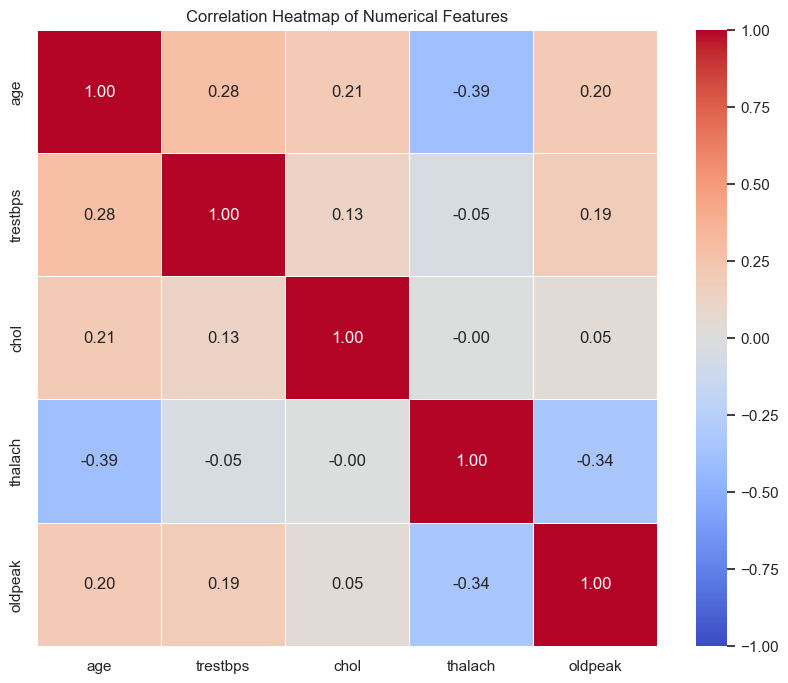

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# ma trận tương quan
corr_matrix = df[numerical_cols].corr()

# Vẽ heatmap
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## Correlation Analysis Summary

The correlation matrix shows generally weak to moderate relationships among numerical features.

- **age** has a moderate negative correlation with **thalach** (−0.39), indicating that maximum heart rate tends to decrease with age.
- **thalach** also shows a moderate negative correlation with **oldpeak** (−0.34), suggesting that lower maximum heart rate is associated with higher ST depression.
- **age** has weak positive correlations with **trestbps**, **chol**, and **oldpeak**, indicating only slight linear relationships.
- **chol** shows very weak correlations with other variables, suggesting limited linear association.
- Overall, no strong correlations are observed, implying low multicollinearity among numerical features.

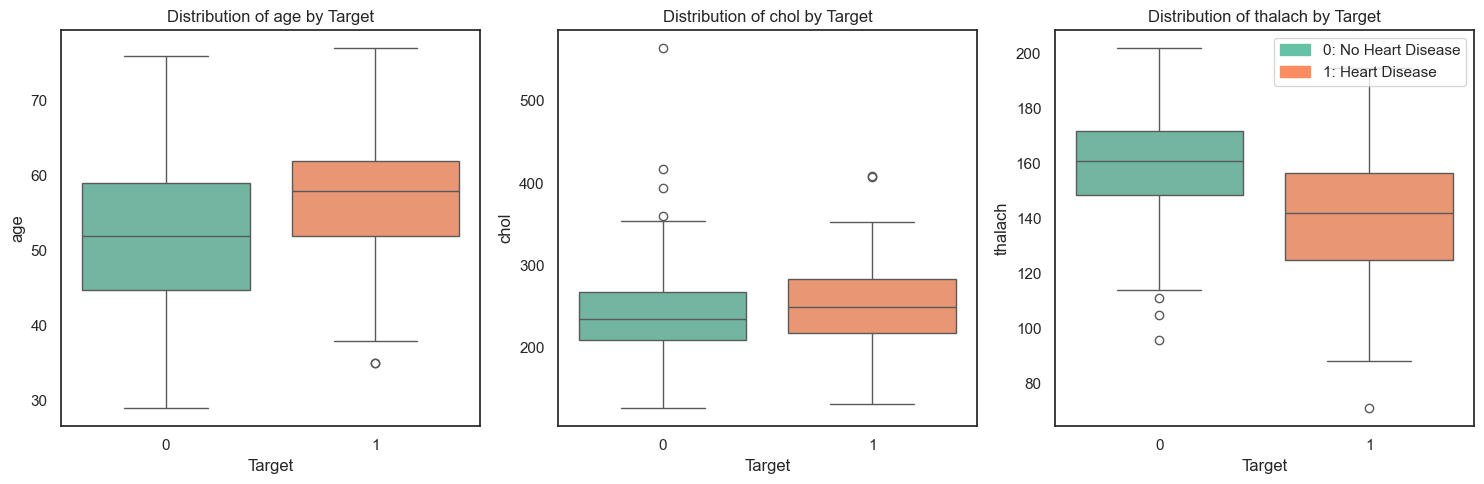

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

key_numerical_features = ['age', 'chol', 'thalach']

plt.figure(figsize=(15, 5))

for i, col in enumerate(key_numerical_features):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(
        x='y',
        y=col,
        data=df,
        palette='Set2'
    )
    plt.title(f'Distribution of {col} by Target')
    plt.xlabel('Target')
    plt.ylabel(col)

# legend
import matplotlib.patches as mpatches
legend_labels = [
    mpatches.Patch(color=sns.color_palette("Set2")[0], label='0: No Heart Disease'),
    mpatches.Patch(color=sns.color_palette("Set2")[1], label='1: Heart Disease')
]
plt.legend(handles=legend_labels, loc='upper right')
plt.tight_layout()
plt.show()


### The boxplots illustrate the distribution of **age**, **cholesterol (chol)**, and **maximum heart rate (thalach)** for patients with and without heart disease.

- **Age:** Patients with heart disease tend to be slightly older than those without the disease.
- **Cholesterol (chol):** Cholesterol levels vary widely in both groups, and the distributions overlap significantly.
- **Thalach:** Patients without heart disease generally achieve a higher maximum heart rate compared to those with heart disease.

**Overall observation:**  
Among these features, **thalach shows the clearest difference between the two groups**, indicating it may be a useful predictor for heart disease classification.

# IV. Train/Test Split

- Dữ liệu được chia 80% train và 20% test, với `stratify=y` để giữ tỷ lệ lớp giữa train và test.

In [64]:
X = df.drop(columns=[target_col, "y"])
y = df["y"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train class ratio:", y_train.value_counts(normalize=True).round(4).to_dict())
print("Test  class ratio:", y_test.value_counts(normalize=True).round(4).to_dict())


Train shape: (242, 13) | Test shape: (61, 13)
Train class ratio: {0: 0.5413, 1: 0.4587}
Test  class ratio: {0: 0.541, 1: 0.459}


# V. Preprocessing Pipeline

Training actually uses `SimpleImputer` inside a Pipeline to avoid data leakage.

- Numeric: median imputation + StandardScaler
- Categorical: most_frequent imputation + OneHotEncoder

In [65]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

print("Preprocessor created.")


Preprocessor created.


# VI. Model

## 10.1 Logistic Regression
<div align="center">
<pre>
X_train
   ↓
Linear combination (wᵀx + b)
   ↓
Sigmoid function
   ↓
Probability P(y=1|x)
   ↓
Log-loss (Cross Entropy)
   ↓
Compute gradient
   ↓
Update parameters (Gradient Descent)
   ↓
Optimized weights
</pre>
</div>

Logistic Regression is a **binary classification algorithm** used to predict the probability that a sample belongs to the positive class (for example: having heart disease).

The model first computes a **linear combination of the input features**:

$$
z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n
$$

Then \(z\) is passed through the **sigmoid function** to convert it into a probability:

$$
P(y=1|x) = \frac{1}{1 + e^{-z}}
$$

The output value is between:

$$
0 < P(y=1|x) < 1
$$

In practice, the model usually uses a **threshold (e.g., 0.5)** to make the final prediction.

**Advantages**
- Easy to understand and explain how the model makes predictions  
- Fast to train and works well when the dataset is not very large  

**Limitations**
- The model can only learn relatively simple relationships between features and the target  
- If the data has very complex or non-linear patterns, the model may not perform well

## 10.2 Support Vector Classifier — Model Explanation

Support Vector Classifier (SVC) is a classification algorithm. The main idea is to find the **best boundary** that separates the classes while keeping the **largest possible distance (margin)** from the closest data points of each class.

If the data can be separated roughly by a **straight line**, SVC with a **linear kernel** works well.  
If the data is more complex and cannot be separated by a straight line, the **RBF kernel** can help the model learn a **curved or more complex decision boundary**.

**Advantages**
- Works well with small or medium-sized datasets  
- Often produces stable classification results  

**Limitations**
- Harder to interpret compared to Logistic Regression  
- Probability estimates are not directly available and may require calibration

In [66]:
models = {
    "Majority": DummyClassifier(strategy="most_frequent"),
    "LogReg_L2": LogisticRegression(penalty="l2", solver="liblinear", max_iter=2000),
    "LogReg_L1": LogisticRegression(penalty="l1", solver="liblinear", max_iter=2000),
    "SVC_Linear": SVC(kernel="linear", C=1.0, probability=True, random_state=42),
    "SVC_RBF": SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42),
}

for name, model in models.items():
    print(name, "->", model)


Majority -> DummyClassifier(strategy='most_frequent')
LogReg_L2 -> LogisticRegression(max_iter=2000, penalty='l2', solver='liblinear')
LogReg_L1 -> LogisticRegression(max_iter=2000, penalty='l1', solver='liblinear')
SVC_Linear -> SVC(kernel='linear', probability=True, random_state=42)
SVC_RBF -> SVC(probability=True, random_state=42)


#Research Question  1

## Logistic Regression vs SVC — ROC-AUC / PR-AUC / F1

In [67]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
}
cv_rows = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model),
    ])

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    cv_rows.append({
        "Model": name,
        "ROC-AUC mean": np.mean(scores["test_roc_auc"]),
        "ROC-AUC std": np.std(scores["test_roc_auc"]),
        "PR-AUC mean": np.mean(scores["test_pr_auc"]),
        "PR-AUC std": np.std(scores["test_pr_auc"]),
        "F1 mean": np.mean(scores["test_f1"]),
        "F1 std": np.std(scores["test_f1"]),
    })

cv_results = pd.DataFrame(cv_rows).sort_values(by="ROC-AUC mean", ascending=False)
print("===== CROSS-VALIDATION RESULTS =====")
print(cv_results.to_string(index=False))


===== CROSS-VALIDATION RESULTS =====
     Model  ROC-AUC mean  ROC-AUC std  PR-AUC mean  PR-AUC std  F1 mean   F1 std
 LogReg_L1      0.920145     0.019095     0.918604    0.023685 0.841028 0.060666
 LogReg_L2      0.918796     0.020713     0.917827    0.026155 0.833226 0.057909
SVC_Linear      0.908176     0.017436     0.911808    0.025455 0.819771 0.054851
   SVC_RBF      0.902143     0.028568     0.903582    0.036039 0.826106 0.050742
  Majority      0.500000     0.000000     0.458743    0.005281 0.000000 0.000000


### Interpretation of CV Results

This table allows us to compare the **stability of different models** using the **mean** and standard deviation (**std**) of **ROC-AUC, PR-AUC, and F1 scores**.

In [68]:
trained_pipelines = {}
test_rows = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model),
    ])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_score = pipe.predict_proba(X_test)[:, 1]

    test_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score),
        "PR-AUC": average_precision_score(y_test, y_score),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
    })
    trained_pipelines[name] = pipe

test_results = pd.DataFrame(test_rows).sort_values(by="ROC-AUC", ascending=False)
print("TEST RESULTS" )
print(test_results.to_string(index=False))


TEST RESULTS
     Model  Accuracy  ROC-AUC   PR-AUC       F1  Precision   Recall
 LogReg_L2  0.885246 0.966450 0.963435 0.881356   0.838710 0.928571
   SVC_RBF  0.885246 0.964286 0.955836 0.881356   0.838710 0.928571
SVC_Linear  0.852459 0.961039 0.957194 0.852459   0.787879 0.928571
 LogReg_L1  0.868852 0.958874 0.954618 0.862069   0.833333 0.892857
  Majority  0.540984 0.500000 0.459016 0.000000   0.000000 0.000000


### Interpretation of Test Results

The test results table directly shows which model performs better on the test set based on AUC, PR-AUC, and F1 scores.

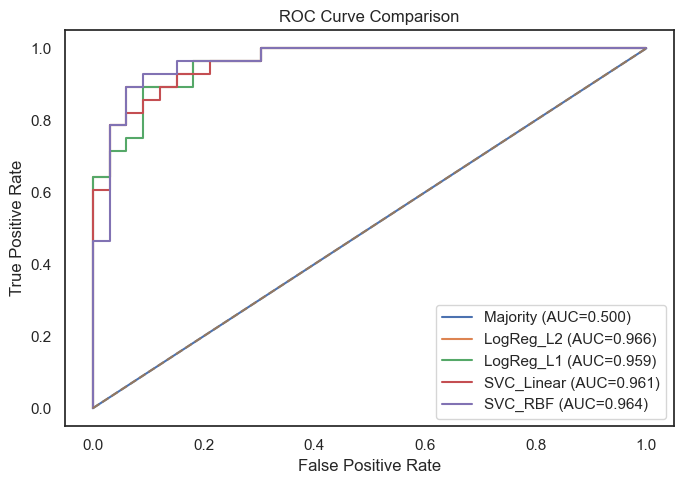

In [69]:
plt.figure(figsize=(7,5))
for name, pipe in trained_pipelines.items():
    y_score = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


### Figure Explanation — ROC Curve Comparison

- The ROC curve is used to evaluate how well a model can distinguish between two classes across different thresholds.  
- The closer the curve is to the **top-left corner** and the higher the **AUC**, the better the model performs.

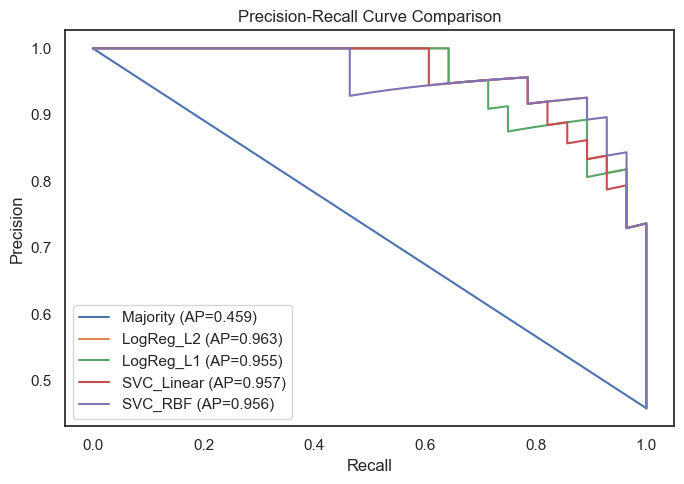

In [70]:
plt.figure(figsize=(7,5))
for name, pipe in trained_pipelines.items():
    y_score = pipe.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()


### Figure Explanation — Precision-Recall Curve

- The Precision–Recall (PR) curve is especially important in medical problems, where the positive class (for example, patients with a disease) needs more attention.

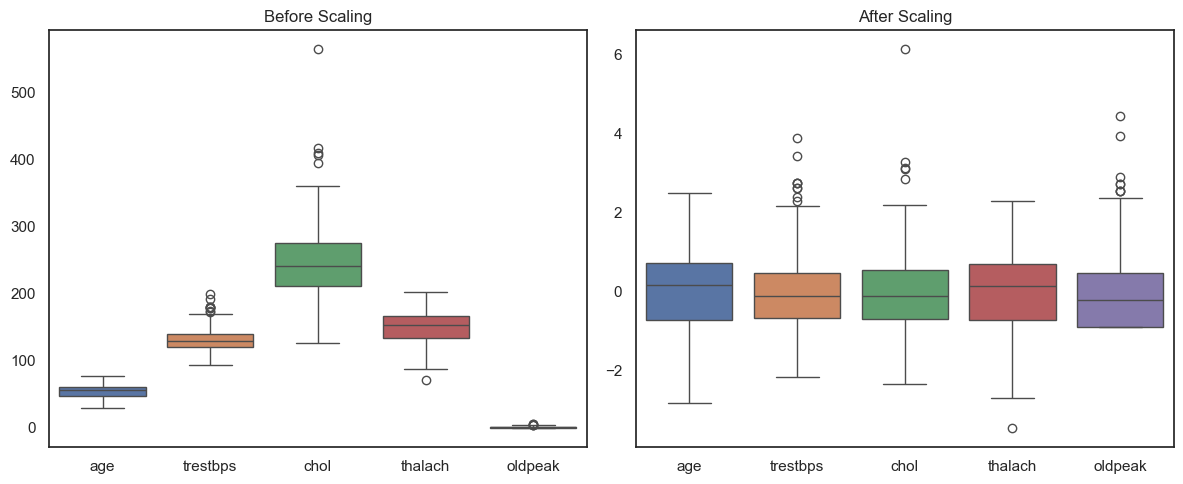

In [71]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
# Lấy dữ liệu gốc
X_num = df[numeric_features].copy()
# Impute giống pipeline
imputer = SimpleImputer(strategy="median")
X_num_imputed = pd.DataFrame(
    imputer.fit_transform(X_num),
    columns=numeric_features
)
# Scale
scaler = StandardScaler()
X_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_num_imputed),
    columns=numeric_features
)
# Vẽ boxplot trước và sau
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(data=X_num_imputed, ax=axes[0])
axes[0].set_title("Before Scaling")

sns.boxplot(data=X_num_scaled, ax=axes[1])
axes[1].set_title("After Scaling")
plt.tight_layout()
plt.show()

#### PR-AUC (Average Precision) Summary

Besides plotting the Precision–Recall curve, this section reports the Average Precision (AP) value explicitly for each model.
This addresses the limitation of reporting only curves without numerical PR-AUC evidence.

In [87]:
ap_rows = []
for name, pipe in trained_pipelines.items():
    y_prob_tmp = pipe.predict_proba(X_test)[:, 1]
    ap_rows.append({
        "Model": name,
        "PR-AUC (AP)": average_precision_score(y_test, y_prob_tmp)
    })

ap_results = pd.DataFrame(ap_rows).sort_values(by="PR-AUC (AP)", ascending=False)
print("PR-AUC / AVERAGE PRECISION RESULTS")
print(ap_results.to_string(index=False))

PR-AUC / AVERAGE PRECISION RESULTS
     Model  PR-AUC (AP)
 LogReg_L2     0.963435
SVC_Linear     0.957194
   SVC_RBF     0.955836
 LogReg_L1     0.954618
  Majority     0.459016


#### Interpretation of PR-AUC Results

This table reports Average Precision (AP) for each classifier.
A higher AP indicates stronger performance on the positive class and is especially important in medical datasets where correctly identifying disease cases is critical.

# Research Question 2
## How does selecting a threshold based on recall or precision affect the trade-off between these two metrics?

In [72]:
logreg_main = trained_pipelines["LogReg_L2"]
y_score_lr = logreg_main.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.91, 0.05)
rows = []

for th in thresholds:
    y_pred_th = (y_score_lr >= th).astype(int)
    rows.append({
        "threshold": th,
        "precision": precision_score(y_test, y_pred_th, zero_division=0),
        "recall": recall_score(y_test, y_pred_th, zero_division=0),
        "f1": f1_score(y_test, y_pred_th, zero_division=0),
    })

threshold_df = pd.DataFrame(rows)
print(threshold_df.to_string(index=False))


 threshold  precision   recall       f1
      0.10   0.636364 1.000000 0.777778
      0.15   0.682927 1.000000 0.811594
      0.20   0.700000 1.000000 0.823529
      0.25   0.736842 1.000000 0.848485
      0.30   0.729730 0.964286 0.830769
      0.35   0.818182 0.964286 0.885246
      0.40   0.818182 0.964286 0.885246
      0.45   0.812500 0.928571 0.866667
      0.50   0.838710 0.928571 0.881356
      0.55   0.862069 0.892857 0.877193
      0.60   0.862069 0.892857 0.877193
      0.65   0.892857 0.892857 0.892857
      0.70   0.923077 0.857143 0.888889
      0.75   0.956522 0.785714 0.862745
      0.80   0.954545 0.750000 0.840000
      0.85   0.947368 0.642857 0.765957
      0.90   1.000000 0.607143 0.755556


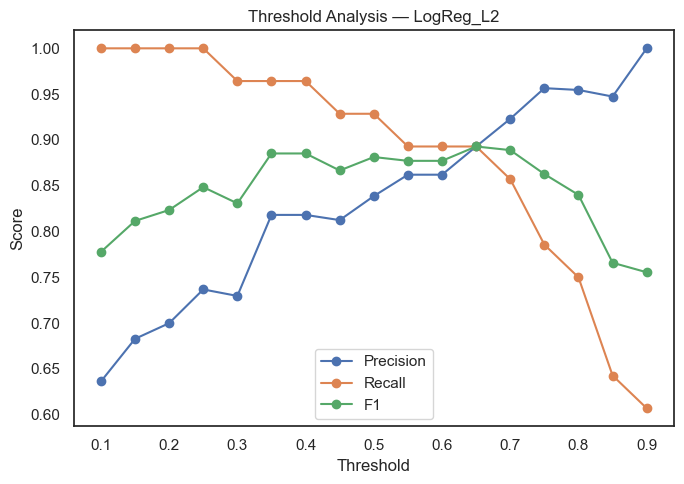

In [73]:
plt.figure(figsize=(7,5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.title("Threshold Analysis — LogReg_L2")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()


### Threshold Trade-off

- This figure shows that a **lower threshold** usually increases **recall**, while a **higher threshold** increases **precision**.  
- The **F1 score** is often highest at some **middle threshold**, where precision and recall are more balanced.

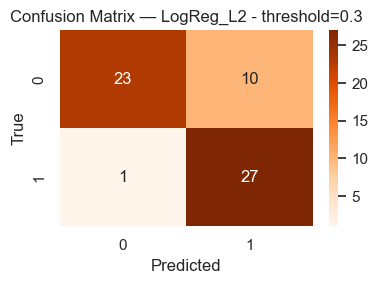

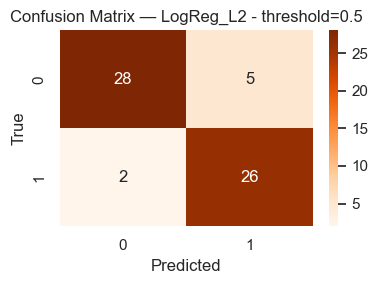

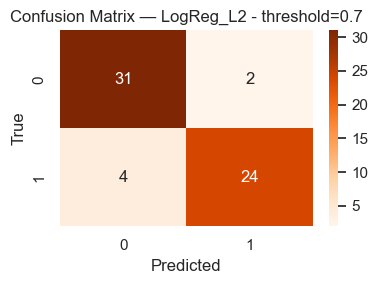

In [74]:
for th in [0.3, 0.5, 0.7]:
    y_pred_th = (y_score_lr >= th).astype(int)
    cm = confusion_matrix(y_test, y_pred_th)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
    plt.title(f"Confusion Matrix — LogReg_L2 - threshold={th}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


###  Confusion Matrix at Different Thresholds

These confusion matrices illustrate how the counts of **true positives, false positives, true negatives, and false negatives** change as the **threshold** changes.

# Research Question 3
## Is the probability calibration of Logistic Regression and SVC good enough to be used as a risk score?

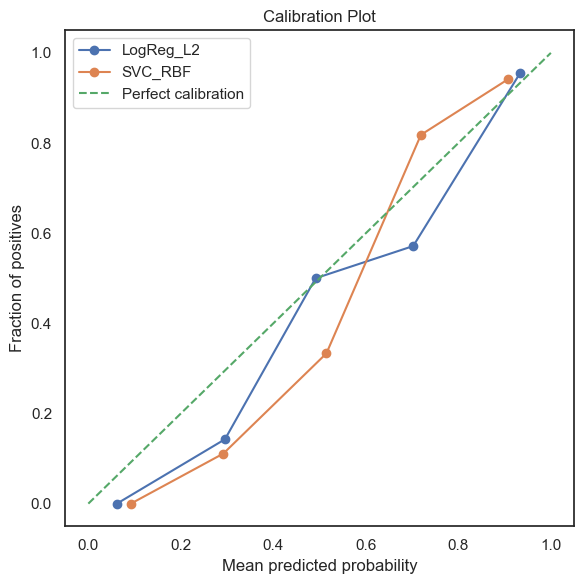

In [75]:
models_for_calibration = ["LogReg_L2", "SVC_RBF"]

plt.figure(figsize=(6,6))
for name in models_for_calibration:
    pipe = trained_pipelines[name]
    y_prob = pipe.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=5)
    plt.plot(mean_pred, frac_pos, marker="o", label=name)

plt.plot([0,1], [0,1], linestyle="--", label="Perfect calibration")
plt.title("Calibration Plot")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.legend()
plt.tight_layout()
plt.show()


###  Calibration Plot

- The calibration plot shows whether the predicted probabilities from the model are close to the actual positive rate. This helps evaluate whether the model’s probabilities can be used as a **risk score**.

In [88]:
from sklearn.metrics import brier_score_loss

models_for_calibration = ["LogReg_L2", "SVC_RBF"]

print("Brier scores (lower is better):")
for name in models_for_calibration:
    pipe = trained_pipelines[name]
    y_prob = pipe.predict_proba(X_test)[:, 1]
    brier = brier_score_loss(y_test, y_prob)
    print(f"{name}: {brier:.4f}")

Brier scores (lower is better):
LogReg_L2: 0.0797
SVC_RBF: 0.0864


# VI Logistic Regression Interpretability

- Logistic Regression has a major advantage in terms of **interpretability**.  
A **positive coefficient** increases the risk of the positive class, while a **negative coefficient** decreases the risk.

- The coefficients can also be converted into **odds ratios** using the formula `exp(coef)`, which makes it easier to understand how each feature affects the predicted risk.

In [81]:
pre = trained_pipelines["LogReg_L2"].named_steps["preprocess"]

feature_names = []
feature_names.extend(numeric_features)

if len(categorical_features) > 0:
    ohe = pre.named_transformers_["cat"].named_steps["onehot"]
    feature_names.extend(list(ohe.get_feature_names_out(categorical_features)))

coef = trained_pipelines["LogReg_L2"].named_steps["model"].coef_.ravel()
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef,
    "odds_ratio": np.exp(coef),
}).sort_values("coef", ascending=False)

print("Top positive coefficients:")
print(coef_df.head(15).to_string(index=False))

print("\nTop negative coefficients:")
print(coef_df.tail(15).to_string(index=False))


Top positive coefficients:
    feature      coef  odds_ratio
     cp_4.0  1.029376    2.799318
   thal_7.0  0.816355    2.262238
    sex_1.0  0.687775    1.989284
     ca_2.0  0.641969    1.900219
  slope_2.0  0.602045    1.825850
     ca_3.0  0.492857    1.636986
     ca_1.0  0.350673    1.420023
   trestbps  0.340511    1.405666
    oldpeak  0.260193    1.297180
  exang_1.0  0.258041    1.294391
restecg_2.0  0.213585    1.238108
       chol  0.178925    1.195930
     cp_2.0  0.153498    1.165905
    fbs_0.0  0.091039    1.095312
        age -0.061535    0.940320

Top negative coefficients:
    feature      coef  odds_ratio
    fbs_0.0  0.091039    1.095312
        age -0.061535    0.940320
restecg_1.0 -0.072040    0.930494
    fbs_1.0 -0.105318    0.900039
restecg_0.0 -0.155823    0.855711
  slope_3.0 -0.175154    0.839327
  exang_0.0 -0.272319    0.761611
   thal_6.0 -0.287340    0.750256
    thalach -0.372224    0.689200
  slope_1.0 -0.441169    0.643284
   thal_3.0 -0.543293    0.

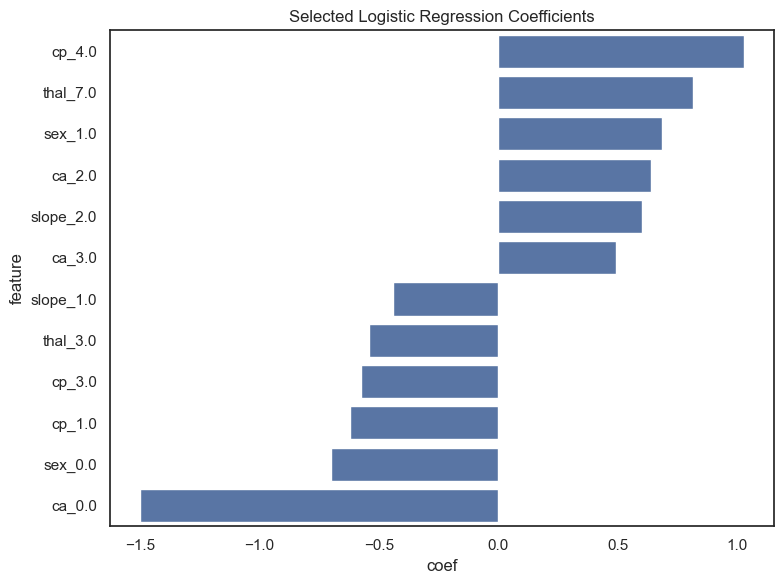

In [82]:
top_show = 12
coef_plot = pd.concat([coef_df.head(top_show//2), coef_df.tail(top_show//2)])

plt.figure(figsize=(8,6))
sns.barplot(data=coef_plot, x="coef", y="feature")
plt.title("Selected Logistic Regression Coefficients")
plt.tight_layout()
plt.show()


###  Logistic Regression Coefficients

The coefficient plot shows the interpretability of Logistic Regression.  
It helps us see which features **increase** or **decrease** the risk.  
In other words, the model not only makes predictions but also gives some explanation about the factors affecting the risk.

#VII Classification Report and Confusion Matrix

- This section summarizes the **precision, recall, F1-score**, and the **confusion matrix** for each model.


===== Majority =====
              precision    recall  f1-score   support

           0       0.54      1.00      0.70        33
           1       0.00      0.00      0.00        28

    accuracy                           0.54        61
   macro avg       0.27      0.50      0.35        61
weighted avg       0.29      0.54      0.38        61

Confusion Matrix:
[[33  0]
 [28  0]]


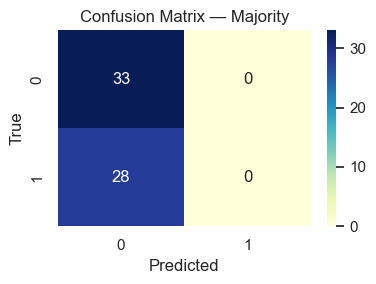


===== LogReg_L2 =====
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61

Confusion Matrix:
[[28  5]
 [ 2 26]]


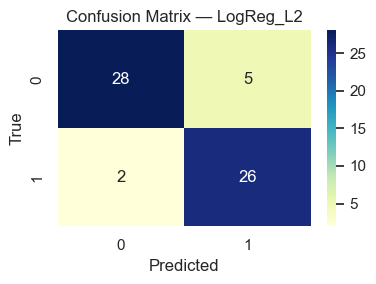


===== LogReg_L1 =====
              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

Confusion Matrix:
[[28  5]
 [ 3 25]]


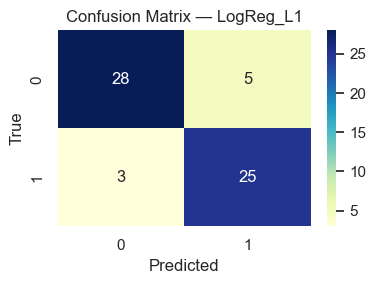


===== SVC_Linear =====
              precision    recall  f1-score   support

           0       0.93      0.79      0.85        33
           1       0.79      0.93      0.85        28

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61

Confusion Matrix:
[[26  7]
 [ 2 26]]


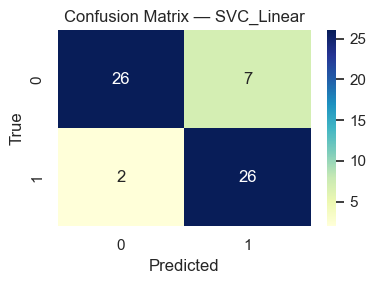


===== SVC_RBF =====
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61

Confusion Matrix:
[[28  5]
 [ 2 26]]


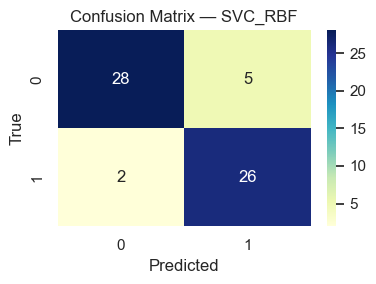

In [83]:
for name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(cm)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu")
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


### Confusion Matrix for Each Model

- Each confusion matrix shows whether a model tends to **miss actual disease cases** or **incorrectly predict disease**.  
- This helps compare the **precision and recall** of different models.

# VIII Best Model Summary

- This section identifies the **best-performing model** based on **ROC-AUC** and **F1 score**.

In [84]:
best_by_auc = test_results.sort_values(by="ROC-AUC", ascending=False).iloc[0]
best_by_f1  = test_results.sort_values(by="F1", ascending=False).iloc[0]

print("Best by ROC-AUC:")
print(best_by_auc.to_string())

print("\nBest by F1:")
print(best_by_f1.to_string())


Best by ROC-AUC:
Model        LogReg_L2
Accuracy      0.885246
ROC-AUC        0.96645
PR-AUC        0.963435
F1            0.881356
Precision      0.83871
Recall        0.928571

Best by F1:
Model        LogReg_L2
Accuracy      0.885246
ROC-AUC        0.96645
PR-AUC        0.963435
F1            0.881356
Precision      0.83871
Recall        0.928571


# IX Pipeline Overview for Report


In [85]:
# print("""
# ========================================
#       HEART DISEASE ML PIPELINE
# ========================================

# Raw Data
#    │
#    ├── Replace '?' -> NaN
#    │
#    ├── Target Transformation
#    │      num = 0   -> y = 0
#    │      num > 0   -> y = 1
#    │
#    ├── Preprocessing
#    │      ├── Numeric   -> Median Imputation -> StandardScaler
#    │      └── Categorical -> Most Frequent Imputation -> OneHotEncoder
#    │
#    ├── Models
#    │      ├── Majority Class
#    │      ├── Logistic Regression (L1 / L2)
#    │      └── SVC (Linear / RBF)
#    │
#    ├── Research Question 1
#    │      Compare ROC-AUC / PR-AUC / F1
#    │
#    ├── Research Question 2
#    │      Threshold trade-off
#    │
#    ├── Research Question 3
#    │      Calibration check
#    │
#    └── Final Recommendation
# """)


In [86]:

# ========================================
#       HEART DISEASE ML PIPELINE
# ========================================

# Raw Data
#    │
#    ├── Replace '?' -> NaN
#    │
#    ├── Target Transformation
#    │      num = 0   -> y = 0
#    │      num > 0   -> y = 1
#    │
#    ├── Preprocessing
#    │      ├── Numeric   -> Median Imputation -> StandardScaler
#    │      └── Categorical -> Most Frequent Imputation -> OneHotEncoder
#    │
#    ├── Models
#    │      ├── Majority Class
#    │      ├── Logistic Regression (L1 / L2)
#    │      └── SVC (Linear / RBF)
#    │
#    ├── Research Question 1
#    │      Compare ROC-AUC / PR-AUC / F1
#    │
# ...
#    │      Calibration check
#    │
#    └── Final Recommendation

# Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...